In [1]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

project_root = '/Users/hugoramossoares/Sites/EasyTemporalPointProcess'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from easy_tpp.model.torch_model.torch_hawkes import Hawkes
from hawkes_data_utils import simulate_hawkes, prepare_batch

print("torch_hawkes e utilitários importados com sucesso")

torch_hawkes e utilitários importados com sucesso


In [2]:
# valores pra geração dos dados sintéticos 
TRUE_MU = 0.3
TRUE_ALPHA = 0.6
TRUE_BETA = 1.3

NUM_TRAIN_SEQS = 200
NUM_TEST_SEQS = 50
T_MAX = 100.0

LEARNING_RATE = 0.005
NUM_EPOCHS = 500  # aumentado para garantir convergência mesmo com inicialização ruim

print("Parâmetros verdadeiros")
print(f"μ = {TRUE_MU}")
print(f"α = {TRUE_ALPHA}")
print(f"β = {TRUE_BETA}")

Parâmetros verdadeiros
μ = 0.3
α = 0.6
β = 1.3


In [3]:
print("Gerando dados de treino...")
train_raw = simulate_hawkes(TRUE_MU, TRUE_ALPHA, TRUE_BETA, NUM_TRAIN_SEQS, T_MAX, seed=42)

print("Gerando dados de teste...")
test_raw = simulate_hawkes(TRUE_MU, TRUE_ALPHA, TRUE_BETA, NUM_TEST_SEQS, T_MAX, seed=123)

# Preparar batches (Hawkes não usa attention_mask, então passamos None)
batch_train = prepare_batch(train_raw, include_attention_mask=False)
batch_test = prepare_batch(test_raw, include_attention_mask=False)

print(f"Dados sintéticos:")
print(f"Treino: {NUM_TRAIN_SEQS} sequências")
print(f"Teste:  {NUM_TEST_SEQS} sequências")
print(f"Shape treino: {batch_train[0].shape}")

Gerando dados de treino...
Gerando dados de teste...
Dados sintéticos:
Treino: 200 sequências
Teste:  50 sequências
Shape treino: torch.Size([200, 114])


In [4]:
# Seed para reprodutibilidade dos pesos iniciais do modelo
# Diferentes seeds resultam em diferentes inicializações
# que podem afetar significativamente a convergência
MODEL_SEED = 42
torch.manual_seed(MODEL_SEED)

class SimpleConfig:
    def __init__(self):
        self.num_event_types_pad = 1 # não eh usado no hawkes
        self.pad_token_id = -1 # não eh usado no hawkes
        self.hidden_size = 64 # não eh usado no hawkes
        self.loss_integral_num_sample_per_step = 0 # não eh usado no hawkes
        self.use_mc_samples = False # não eh usado no hawkes
        self.thinning = None # não eh usado no hawkes
        self.gpu = -1
        self.num_event_types = 1

config = SimpleConfig()
model = Hawkes(config)

print("Modelo criado!")
print(f"\nParâmetros Iniciais (seed={MODEL_SEED}):")
print(f"μ = {model.mu.item():.4f}")
print(f"α = {model.alpha.item():.4f}")
print(f"β = {model.beta.item():.4f}")

Modelo criado!

Parâmetros Iniciais (seed=42):
μ = 0.8165
α = 1.2157
β = 0.3091


In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

losses_train = []
losses_test = []

print("Iniciando treinamento...\n")

for epoch in range(1, NUM_EPOCHS + 1):
    optimizer.zero_grad()
    
    loss, num_events = model.loglike_loss(batch_train)
    nll_train = loss / num_events
    
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # limita o gradiente 
    optimizer.step()
    
    losses_train.append(nll_train.item())
    
    with torch.no_grad():
        loss_test, num_test = model.loglike_loss(batch_test)
        nll_test = loss_test / num_test
        losses_test.append(nll_test.item())
    
    if epoch % 50 == 0:
        print(f"Ep {epoch:3d} | Train NLL: {nll_train.item():.4f} | Test NLL: {nll_test.item():.4f} | "
              f"μ={model.mu.item():.3f} α={model.alpha.item():.3f} β={model.beta.item():.3f}")

print("\nTreinamento concluído!")

Iniciando treinamento...

Ep  50 | Train NLL: 2.9555 | Test NLL: 2.9753 | μ=0.682 α=1.046 β=0.381
Ep 100 | Train NLL: 2.2319 | Test NLL: 2.2529 | μ=0.556 α=0.887 β=0.465
Ep 150 | Train NLL: 1.7763 | Test NLL: 1.7973 | μ=0.443 α=0.743 β=0.560
Ep 200 | Train NLL: 1.5252 | Test NLL: 1.5457 | μ=0.348 α=0.614 β=0.666
Ep 250 | Train NLL: 1.4273 | Test NLL: 1.4474 | μ=0.279 α=0.500 β=0.788
Ep 300 | Train NLL: 1.4135 | Test NLL: 1.4351 | μ=0.315 α=0.445 β=0.946
Ep 350 | Train NLL: 1.4099 | Test NLL: 1.4325 | μ=0.322 α=0.517 β=1.132
Ep 400 | Train NLL: 1.4083 | Test NLL: 1.4322 | μ=0.331 α=0.594 β=1.340
Ep 450 | Train NLL: 1.4082 | Test NLL: 1.4325 | μ=0.334 α=0.618 β=1.410
Ep 500 | Train NLL: 1.4082 | Test NLL: 1.4325 | μ=0.334 α=0.618 β=1.408

Treinamento concluído!


In [6]:
print("Resultado final")

print(f"\nParâmetros verdadeiros:")
print(f"μ = {TRUE_MU}")
print(f"α = {TRUE_ALPHA}")
print(f"β = {TRUE_BETA}")

print(f"\nParâmetros aprendidos:")
print(f"μ = {model.mu.item():.4f}")
print(f"α = {model.alpha.item():.4f}")
print(f"β = {model.beta.item():.4f}")

mae_mu = abs(model.mu.item() - TRUE_MU)
mae_alpha = abs(model.alpha.item() - TRUE_ALPHA)
mae_beta = abs(model.beta.item() - TRUE_BETA)
mae_total = (mae_mu + mae_alpha + mae_beta) / 3

print(f"\nErro absoluto por parâmetro:")
print(f"MAE(μ) = {mae_mu:.4f}")
print(f"MAE(α) = {mae_alpha:.4f}")
print(f"MAE(β) = {mae_beta:.4f}")
print(f"MAE Total = {mae_total:.4f}")

Resultado final

Parâmetros verdadeiros:
μ = 0.3
α = 0.6
β = 1.3

Parâmetros aprendidos:
μ = 0.3339
α = 0.6180
β = 1.4076

Erro absoluto por parâmetro:
MAE(μ) = 0.0339
MAE(α) = 0.0180
MAE(β) = 0.1076
MAE Total = 0.0531


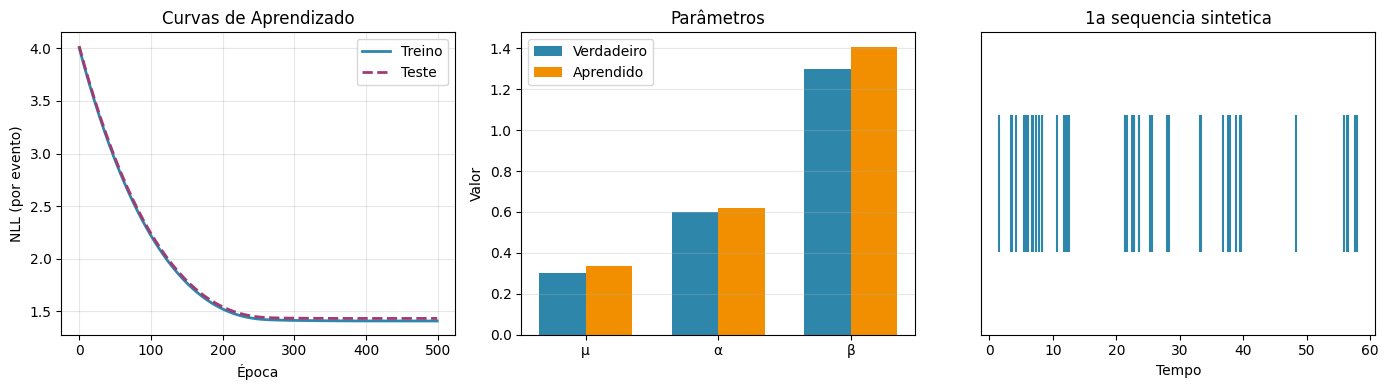

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Curvas de Aprendizado
axes[0].plot(losses_train, label='Treino', color='#2E86AB', linewidth=2)
axes[0].plot(losses_test, label='Teste', color='#A23B72', linewidth=2, linestyle='--')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('NLL (por evento)')
axes[0].set_title('Curvas de Aprendizado')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Comparação de Parâmetros
params = ['μ', 'α', 'β']
true_vals = [TRUE_MU, TRUE_ALPHA, TRUE_BETA]
learned_vals = [model.mu.item(), model.alpha.item(), model.beta.item()]

x = np.arange(len(params))
width = 0.35

axes[1].bar(x - width/2, true_vals, width, label='Verdadeiro', color='#2E86AB')
axes[1].bar(x + width/2, learned_vals, width, label='Aprendido', color='#F18F01')
axes[1].set_xticks(x)
axes[1].set_xticklabels(params)
axes[1].set_ylabel('Valor')
axes[1].set_title('Parâmetros')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# 3. Exemplo de Sequência
example_seq = train_raw[0][:50]  # Primeiros 50 eventos
axes[2].eventplot([example_seq], colors='#2E86AB', lineoffsets=0, linelengths=0.5)
axes[2].set_xlabel('Tempo')
axes[2].set_title('1a sequencia sintetica')
axes[2].set_yticks([])

plt.tight_layout()
plt.show()
